# Pairwise Gaussian Limit Comparison

This notebook compares the simulated pairwise Gaussian integral approximations in `pairwise_gaussian_estimate1` against the empirical pairwise Wasserstein distributions saved in `AVMs5a`.


In [ ]:
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PAIRWISE_GAUSSIAN_ROOT = Path("pairwise_gaussian_estimate1")
AVM_ROOT = Path("AVMs5b")
GROUPS = ("paths1",) # "paths2")
OBSERVABLES = ("theta1", "w1", "theta2", "w2")
EMPIRICAL_SCALE = np.sqrt(100_002 - 50_000)
LABELS = {
    "theta1": r"theta_1",
    "w1": r"omega_1",
    "theta2": r"theta_2",
    "w2": r"omega_2",
}


def load_pairwise_gaussian(group: str, observable: str) -> np.ndarray:
    path = PAIRWISE_GAUSSIAN_ROOT / group / f"{observable}_pairwise_gaussian_integrals.npy"
    if not path.exists():
        raise FileNotFoundError(f"Missing Gaussian simulation file: {path}")
    values = np.load(path)
    return np.asarray(values, dtype=float)


@lru_cache(maxsize=None)
def load_avm_workbook(group: str) -> dict[str, pd.DataFrame]:
    workbook = AVM_ROOT / f"{group}_results.xlsx"
    if not workbook.exists():
        raise FileNotFoundError(f"Missing AVMs5a workbook: {workbook}")
    return pd.read_excel(workbook, sheet_name=None, index_col=0)


def load_avm_pairwise_values(group: str, observable: str) -> np.ndarray:
    workbook_sheets = load_avm_workbook(group)
    if observable not in workbook_sheets:
        raise KeyError(f"Sheet {observable!r} not found in AVMs5a workbook for {group}")

    matrix_df = workbook_sheets[observable]
    matrix = matrix_df.to_numpy(dtype=float)
    upper_triangle_mask = np.triu(np.ones(matrix.shape, dtype=bool), k=1)
    values = matrix[upper_triangle_mask & np.isfinite(matrix)]
    return EMPIRICAL_SCALE * values


def compare_group(group: str, bins: int = 40) -> pd.DataFrame:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    axes = axes.ravel()
    summary_rows = []

    for ax, observable in zip(axes, OBSERVABLES):
        gaussian_values = load_pairwise_gaussian(group, observable)
        avm_values = load_avm_pairwise_values(group, observable)

        combined = np.concatenate([gaussian_values, avm_values])
        bin_edges = np.linspace(combined.min(), combined.max(), bins + 1)

        ax.hist(
            avm_values,
            bins=bin_edges,
            density=True,
            alpha=0.45,
            color="#c44e52",
            label=r"Scaled AVMs5a pairwise",
        )
        ax.hist(
            gaussian_values,
            bins=bin_edges,
            density=True,
            alpha=0.45,
            color="#4c72b0",
            label="Gaussian pairwise limit",
        )

        ax.set_title(f"{group}: {LABELS[observable]}")
        ax.set_xlabel("value")
        ax.set_ylabel("density")
        ax.legend(frameon=False)

        summary_rows.append(
            {
                "group": group,
                "observable": observable,
                "avm_count": avm_values.size,
                "gaussian_count": gaussian_values.size,
                "avm_mean": avm_values.mean(),
                "gaussian_mean": gaussian_values.mean(),
                "avm_std": avm_values.std(ddof=1),
                "gaussian_std": gaussian_values.std(ddof=1),
            }
        )

    fig.suptitle(f"{group}: scaled AVMs5a vs pairwise Gaussian limit", fontsize=16)
    plt.show()
    return pd.DataFrame(summary_rows)


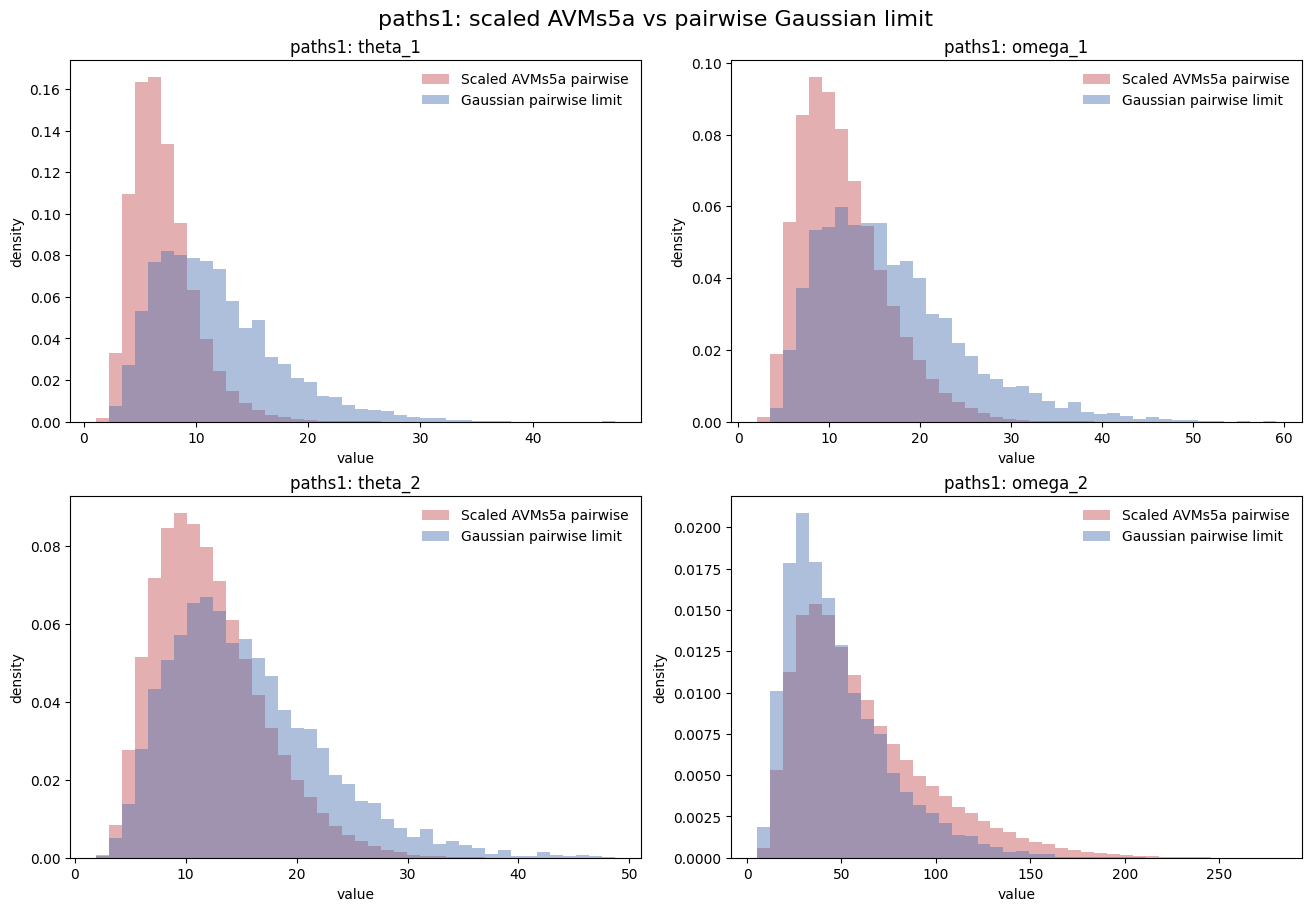

,group,observable,avm_count,gaussian_count,avm_mean,gaussian_mean,avm_std,gaussian_std
0,paths1,theta1,499500,5000,7.082092,11.718877,2.761852,5.473130
1,paths1,w1,499500,5000,11.525522,16.691342,4.735895,7.926878
2,paths1,theta2,499500,5000,12.192585,15.547610,4.913149,7.012803
3,paths1,w2,499500,5000,61.699618,48.168458,36.099663,27.329534


In [2]:
summaries = []
for group in GROUPS:
    summaries.append(compare_group(group))

summary_df = pd.concat(summaries, ignore_index=True)
summary_df
